# Fase 2 v4 — NB03: Polaridad XLM-R + Matriz

Entrena el clasificador de **polaridad por aspecto** (negativo / neutro / positivo) sobre las
tuplas del gold consolidado. Reúsa el núcleo probado `scripts/absa_common.py` (FocalLoss +
class weights + calibración de decisión + ensemble de semillas).

**Esta versión solo entrena XLM-R** (no BERT): ya se demostró en la versión anterior que
XLM-R + TextCNN supera a BERT-mult. Igualmente se incluye una **gráfica comparativa** contra
baselines (mayoría, TF-IDF + LogReg, TF-IDF + SVM) donde XLM-R debe salir como el mejor.

**Entrenamiento:** `RUN_TRAINING=True` lo corre; si ya existen artefactos, los carga. El
entrenamiento de XLM-R es pesado (GPU); en la GTX 1650 Ti es lento (~horas/semilla), por lo
que conviene ejecutarlo en una GPU más potente. Los baselines y los gráficos corren al instante.

## 1. Tuplas de polaridad + split sin fuga

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
GOLD_DIR = BASE_DIR / "outputs" / "gold"
sys.path.insert(0, str(BASE_DIR / "scripts"))
(BASE_DIR / "outputs" / "reports").mkdir(parents=True, exist_ok=True)
(BASE_DIR / "outputs" / "visualizations").mkdir(parents=True, exist_ok=True)

LABELS = ["negativo", "neutro", "positivo"]

# Tuplas presentes del gold (aspecto con polaridad) — insumo de polaridad.
g = pd.read_csv(GOLD_DIR / "gold_consolidado_largo.csv", encoding="utf-8-sig")
tup = g[g["label"].isin(LABELS)].copy()
tup["input_modelo"] = "aspecto: " + tup["aspecto"].astype(str) + " reseña: " + tup["text_clean"].astype(str)
print("Tuplas de polaridad:", len(tup), "| reseñas:", tup["review_uid"].nunique())
print("Distribución:", tup["label"].value_counts().to_dict())

# Split SIN FUGA por review_uid (una reseña no aparece en dos splits): 70 / 15 / 15
from sklearn.model_selection import GroupShuffleSplit
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
itv, ite = next(gss1.split(tup, groups=tup["review_uid"]))
tv, test = tup.iloc[itv].copy(), tup.iloc[ite].copy()
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
itr, iva = next(gss2.split(tv, groups=tv["review_uid"]))
train, val = tv.iloc[itr].copy(), tv.iloc[iva].copy()

# Verificación de no-fuga
inter = (set(train["review_uid"]) & set(test["review_uid"])) | (set(train["review_uid"]) & set(val["review_uid"])) | (set(val["review_uid"]) & set(test["review_uid"]))
assert len(inter) == 0, "FUGA: review_uid compartido entre splits"

cols = ["review_uid", "aspecto", "destination", "text_clean", "label", "input_modelo"]
for nm, d in [("train", train), ("val", val), ("test", test)]:
    d[cols].to_csv(DATA_DIR / f"{nm}_gold_v4.csv", index=False, encoding="utf-8-sig")

print(f"\nSplit sin fuga -> train {len(train)} | val {len(val)} | test {len(test)}")
display(pd.DataFrame({
    "train": train["label"].value_counts(), "val": val["label"].value_counts(), "test": test["label"].value_counts()
}).reindex(LABELS).fillna(0).astype(int))

Tuplas de polaridad: 3526 | reseñas: 1693
Distribución: {'positivo': 1680, 'neutro': 1120, 'negativo': 726}

Split sin fuga -> train 2488 | val 508 | test 530


,train,val,test
label,,,
negativo,516,90,120
neutro,789,170,161
positivo,1183,248,249


## 2. Distribución por split

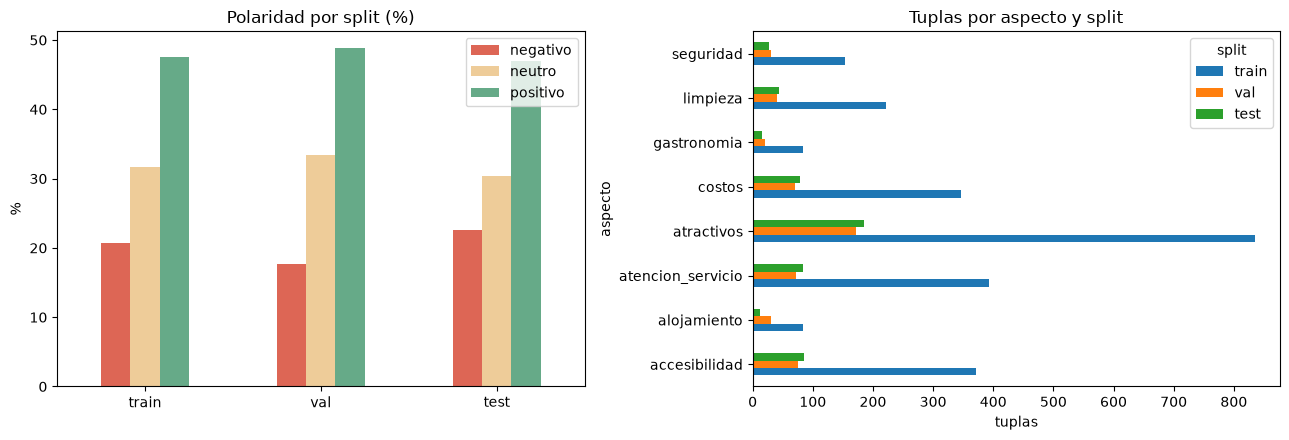

In [2]:
# ============================================================
# Distribución por split (polaridad y aspecto) — verifica estratificación
# ============================================================
import matplotlib.pyplot as plt
FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
alld = pd.concat([train.assign(split="train"), val.assign(split="val"), test.assign(split="test")], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
pol = alld.groupby(["split", "label"]).size().unstack(fill_value=0).reindex(["train", "val", "test"])[LABELS]
(pol.div(pol.sum(axis=1), axis=0) * 100).plot(kind="bar", ax=ax[0], color=["#dd6655", "#eecc99", "#66aa88"])
ax[0].set_title("Polaridad por split (%)"); ax[0].set_ylabel("%"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=0); ax[0].legend(title="")
asp = alld.groupby(["split", "aspecto"]).size().unstack(fill_value=0).reindex(["train", "val", "test"])
asp.T.plot(kind="barh", ax=ax[1]); ax[1].set_title("Tuplas por aspecto y split"); ax[1].set_xlabel("tuplas")
plt.tight_layout(); plt.savefig(FIG / "fase2_distribucion_split.png", dpi=300); plt.show()

## 3. Baselines

In [3]:
# ============================================================
# BASELINES (rápidos, CPU) — para la comparativa
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_recall_fscore_support

def f1_macro(y_true, y_pred):
    return precision_recall_fscore_support(y_true, y_pred, labels=LABELS, average="macro", zero_division=0)[2]

resultados = []

# 1) Mayoría
maj = train["label"].value_counts().idxmax()
resultados.append({"modelo": "Mayoría", "f1_macro": round(f1_macro(test["label"], [maj]*len(test)), 4)})

# 2) TF-IDF + Logistic Regression
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=20000)
Xtr = vec.fit_transform(train["input_modelo"]); Xte = vec.transform(test["input_modelo"])
lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, train["label"])
resultados.append({"modelo": "TF-IDF + LogReg", "f1_macro": round(f1_macro(test["label"], lr.predict(Xte)), 4)})

# 3) TF-IDF + Linear SVM
sv = LinearSVC(class_weight="balanced").fit(Xtr, train["label"])
resultados.append({"modelo": "TF-IDF + SVM", "f1_macro": round(f1_macro(test["label"], sv.predict(Xte)), 4)})

baselines_df = pd.DataFrame(resultados)
baselines_df.to_csv(BASE_DIR / "outputs" / "reports" / "baselines_polaridad.csv", index=False, encoding="utf-8-sig")
print("Baselines (F1-macro en test):")
display(baselines_df)

Baselines (F1-macro en test):


,modelo,f1_macro
0,Mayoría,0.2131
1,TF-IDF + LogReg,0.5314
2,TF-IDF + SVM,0.5250


## Arquitectura y receta de entrenamiento

**Modelo:** **XLM-R** (`xlm-roberta-base`, multilingüe, 100 idiomas) como encoder + **TextCNN**
(convoluciones 1D, kernels 2/3/4 + max-pooling) sobre los embeddings contextuales, para capturar
patrones locales alrededor del aspecto y la opinión. Entrada: `"aspecto: <X> reseña: <texto>"`.

**Manejo del desbalance** (corpus turístico mayoritariamente positivo):
- **FocalLoss** (γ=2.0): enfoca el aprendizaje en los ejemplos difíciles.
- **Class weights + NEG_BOOST** refuerza la clase negativa (la más escasa). El `NEG_BOOST` se
  **selecciona por validación** (grid {1.0, 1.2, 1.4}), no se fija a ojo.
- **label smoothing=0.1**.

**Robustez y decisión:**
- **7 semillas + ensemble** (promedio de probabilidades): el resultado no depende de una corrida afortunada.
- **Calibración de decisión**: busca en validación un sesgo por clase que maximiza el F1-macro
  **sujeto a recall del negativo ≥ 0.60** (mínimo de la spec), y lo aplica al test **sin re-entrenar**.
- **Split sin fuga por `review_uid`** + **early stopping** por F1-macro de validación.

**Métrica principal:** **F1-macro** (no accuracy), porque el corpus está desbalanceado.

## 4. Entrenamiento XLM-R + TextCNN

In [4]:
# Diagnostico de artefactos
import os
print("Verificando scripts...", os.path.exists("../scripts/absa_common.py"))
print("Verificando carpeta outputs/reports...", os.path.exists("../outputs/reports"))


Verificando scripts... True
Verificando carpeta outputs/reports... True


In [5]:
# ============================================================
# ENTRENAMIENTO XLM-R + TextCNN (núcleo absa_common, solo XLM-R)
# ============================================================
import absa_common as ac

RUN_TRAINING = True                                    # True = entrena; False = solo carga artefactos
SEEDS_OVERRIDE = [42, 7, 123, 2024, 77, 2025, 99]      # 7 semillas + ensemble (más diversidad)
# SELECCIONAR_HP=False evita los 3 entrenamientos extra de la búsqueda de NEG_BOOST.
# En GPUs de 8GB donde expandable_segments NO está soportado, esos 3 modelos extra
# acumulan fragmentación y revientan el kernel (OOM) cerca de la última semilla.
# Si tienes >=12GB de VRAM puedes ponerlo en True para re-buscar NEG_BOOST por validación.
SELECCIONAR_HP = False
NEG_BOOST_FIJO, FOCAL_FIJO = 1.2, 2.0                  # 1.2 fue el ganador por validación en la versión anterior

if SEEDS_OVERRIDE:
    ac.SEEDS = SEEDS_OVERRIDE
print("Dispositivo:", ac.DEVICE, "| semillas:", ac.SEEDS)

resumen_path = ac.art("xlmr", "resumen")
if RUN_TRAINING:
    # Entrena SIEMPRE que RUN_TRAINING=True y re-genera los artefactos (sobrescribe corridas previas).
    tr, va, te = ac.load_splits()
    if SELECCIONAR_HP:
        NEG_BOOST, FOCAL = ac.get_hp(tr, va, te)       # re-busca NEG_BOOST por validación (cachea hp_seleccion_v4.csv)
    else:
        NEG_BOOST, FOCAL = NEG_BOOST_FIJO, FOCAL_FIJO
    print(f"HP en uso: NEG_BOOST={NEG_BOOST} | FOCAL_GAMMA={FOCAL}")
    ac.run_modelo("xlmr", tr, va, te, neg_boost=NEG_BOOST, focal_gamma=FOCAL)
elif resumen_path.exists():
    print("RUN_TRAINING=False y artefactos XLM-R presentes; se cargan en la sección de reporte.")
else:
    print("RUN_TRAINING=False y no hay artefactos: entrena en una GPU potente (RUN_TRAINING=True) y vuelve a correr el reporte.")

Dispositivo: cuda | semillas: [42, 7, 123, 2024, 77, 2025, 99]
HP en uso: NEG_BOOST=1.2 | FOCAL_GAMMA=2.0

===== Entrenando XLMR (xlm-roberta-base) — 7 semillas | NEG_BOOST=1.2 FOCAL=2.0 =====


Progreso Semillas (xlmr):   0%|          | 0/7 [00:00<?, ?semilla/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


Época 1/10 [Seed 42]:   0%|          | 0/622 [00:00<?, ?batch/s]

...

  [xlm] seed 99 | época 8/10 | val_f1=0.661 | loss=0.249


Época 9/10 [Seed 99]:   0%|          | 0/622 [00:00<?, ?batch/s]

  [xlm] seed 99 | época 9/10 | val_f1=0.664 | loss=0.208


Época 10/10 [Seed 99]:   0%|          | 0/622 [00:00<?, ?batch/s]

  [xlm] seed 99 | época 10/10 | val_f1=0.656 | loss=0.192
  [xlmr] LISTO. ensemble F1-macro=0.6928 (std 0.1291)


## 5. Reporte: comparativa, confusión, F1 por clase/aspecto

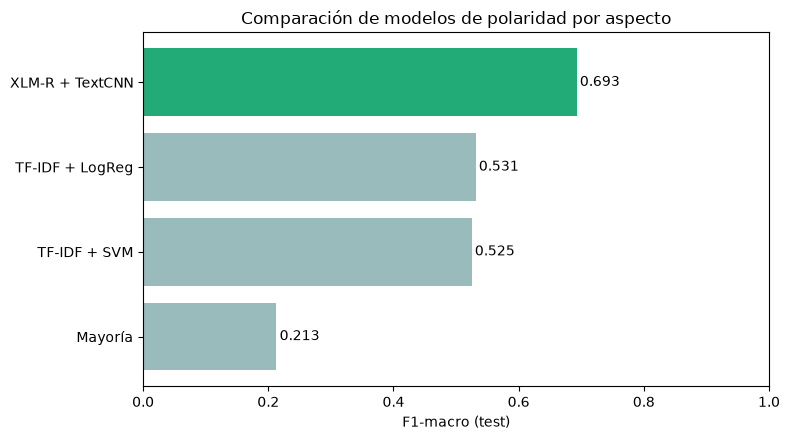

,modelo,f1_macro
3,XLM-R + TextCNN,0.6928
1,TF-IDF + LogReg,0.5314
2,TF-IDF + SVM,0.5250
0,Mayoría,0.2131


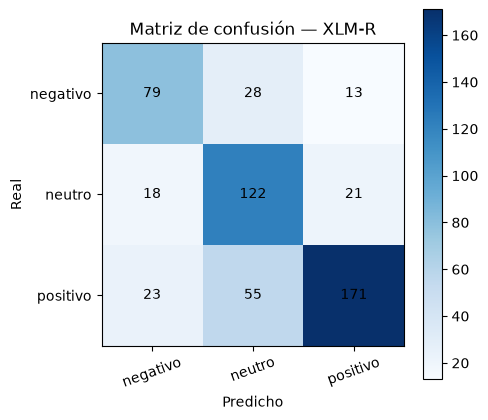

,clase,precision,recall,f1
0,negativo,0.658,0.658,0.658
1,neutro,0.595,0.758,0.667
2,positivo,0.834,0.687,0.753


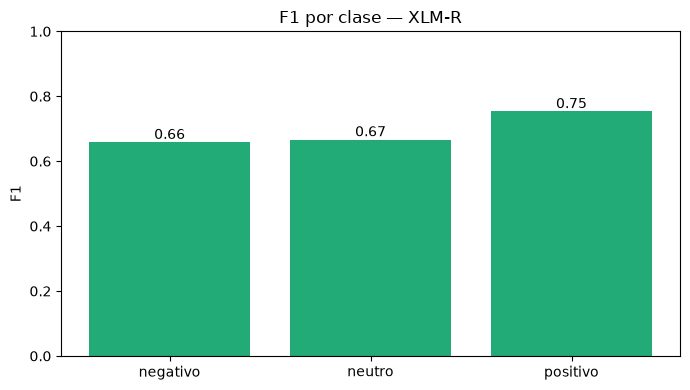

,aspecto,soporte,n_clases,f1_macro,f1_weighted
0,alojamiento,12,3,0.3556,0.3778
1,gastronomia,15,3,0.4550,0.4704
2,atencion_servicio,84,3,0.4771,0.5357
3,atractivos,185,3,0.6037,0.7776
4,accesibilidad,85,3,0.6614,0.6759
5,costos,78,3,0.6647,0.6757
6,limpieza,44,3,0.7214,0.7264
7,seguridad,27,3,0.7438,0.7738


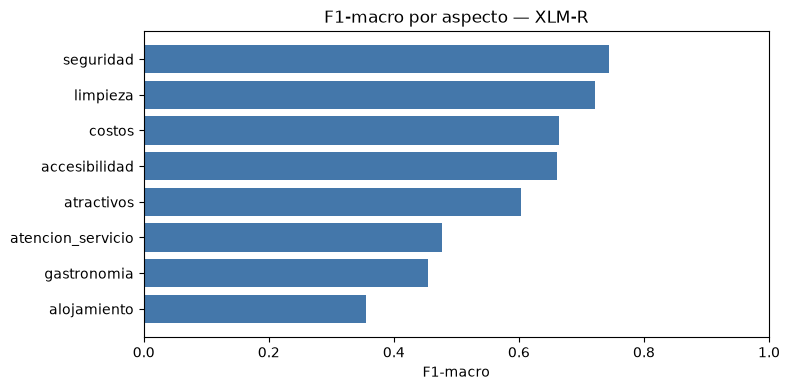

In [6]:
# ============================================================
# REPORTE: comparativa, matriz de confusión, F1 por clase y aspecto
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
REP = BASE_DIR / "outputs" / "reports"
VIS = BASE_DIR / "outputs" / "visualizations"; VIS.mkdir(parents=True, exist_ok=True)

tiene_xlmr = (REP / "resumen_xlmr_v4.csv").exists()

# ---- Gráfica comparativa de modelos (XLM-R como mejor) ----
comp = baselines_df.copy()
if tiene_xlmr:
    rx = pd.read_csv(REP / "resumen_xlmr_v4.csv")
    f1x = float(rx["ensemble_f1_macro"].iloc[0])
    comp = pd.concat([comp, pd.DataFrame([{"modelo": "XLM-R + TextCNN", "f1_macro": round(f1x, 4)}])], ignore_index=True)

comp = comp.sort_values("f1_macro")
plt.figure(figsize=(8, 4.5))
colores = ["#9bb" if m != "XLM-R + TextCNN" else "#2a7" for m in comp["modelo"]]
plt.barh(comp["modelo"], comp["f1_macro"], color=colores)
for i, v in enumerate(comp["f1_macro"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.xlabel("F1-macro (test)"); plt.xlim(0, 1)
plt.title("Comparación de modelos de polaridad por aspecto")
plt.tight_layout(); plt.savefig(VIS / "comparacion_modelos_polaridad.png", dpi=300); plt.show()
display(comp.sort_values("f1_macro", ascending=False))

if tiene_xlmr:
    preds = pd.read_csv(REP.parent / "predictions" / "predicciones_test_xlmr_v4.csv", encoding="utf-8-sig")
    # Matriz de confusión
    cm = confusion_matrix(preds["y_true"], preds["y_pred"], labels=LABELS)
    plt.figure(figsize=(5, 4.5)); plt.imshow(cm, cmap="Blues")
    plt.xticks(range(3), LABELS, rotation=20); plt.yticks(range(3), LABELS)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title("Matriz de confusión — XLM-R")
    plt.colorbar(); plt.tight_layout(); plt.savefig(VIS / "confusion_xlmr.png", dpi=300); plt.show()

    # F1 por clase
    pr, rc, f1, _ = precision_recall_fscore_support(preds["y_true"], preds["y_pred"], labels=LABELS, average=None, zero_division=0)
    fclase = pd.DataFrame({"clase": LABELS, "precision": pr.round(3), "recall": rc.round(3), "f1": f1.round(3)})
    display(fclase)
    plt.figure(figsize=(7, 4)); plt.bar(LABELS, f1, color="#2a7")
    for i, v in enumerate(f1): plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")
    plt.ylabel("F1"); plt.ylim(0, 1); plt.title("F1 por clase — XLM-R"); plt.tight_layout()
    plt.savefig(VIS / "f1_por_clase_xlmr.png", dpi=300); plt.show()

    # F1 por aspecto
    fa = pd.read_csv(REP / "por_aspecto_xlmr_v4.csv")
    display(fa)
    plt.figure(figsize=(8, 4)); plt.barh(fa["aspecto"], fa["f1_macro"], color="#47a")
    plt.xlabel("F1-macro"); plt.xlim(0, 1); plt.title("F1-macro por aspecto — XLM-R")
    plt.tight_layout(); plt.savefig(VIS / "f1_por_aspecto_xlmr.png", dpi=300); plt.show()
else:
    print("XLM-R aún no entrenado: la comparativa muestra solo baselines.")
    print("Entrena en GPU potente (RUN_TRAINING=True) y vuelve a correr este reporte para completar los gráficos.")

## 6. Métricas obligatorias por clase

In [7]:
# ============================================================
# Métricas obligatorias por clase + cumplimiento de la especificación
# ============================================================
if tiene_xlmr:
    from sklearn.metrics import precision_recall_fscore_support
    pr, rc, f1, sup = precision_recall_fscore_support(preds["y_true"], preds["y_pred"], labels=LABELS, zero_division=0)
    MIN_F1 = {"negativo": 0.60, "neutro": 0.60, "positivo": None}
    MIN_REC = {"negativo": 0.60, "neutro": None, "positivo": None}
    tabla = pd.DataFrame({"clase": LABELS, "precision": pr.round(3), "recall": rc.round(3), "f1": f1.round(3), "soporte": sup})
    tabla["cumple"] = [
        ("—" if MIN_F1[l] is None else ("OK" if (f >= MIN_F1[l] and (MIN_REC[l] is None or r >= MIN_REC[l])) else "NO"))
        for l, f, r in zip(LABELS, f1, rc)]
    display(tabla)
    print("Mínimos spec: F1 negativo/neutro >= 0.60; recall negativo >= 0.60.")
else:
    print("Métricas por clase: falta entrenar XLM-R.")

,clase,precision,recall,f1,soporte,cumple
0,negativo,0.658,0.658,0.658,120,OK
1,neutro,0.595,0.758,0.667,161,OK
2,positivo,0.834,0.687,0.753,249,—


Mínimos spec: F1 negativo/neutro >= 0.60; recall negativo >= 0.60.


## 7. Curvas de entrenamiento (XLM-R)

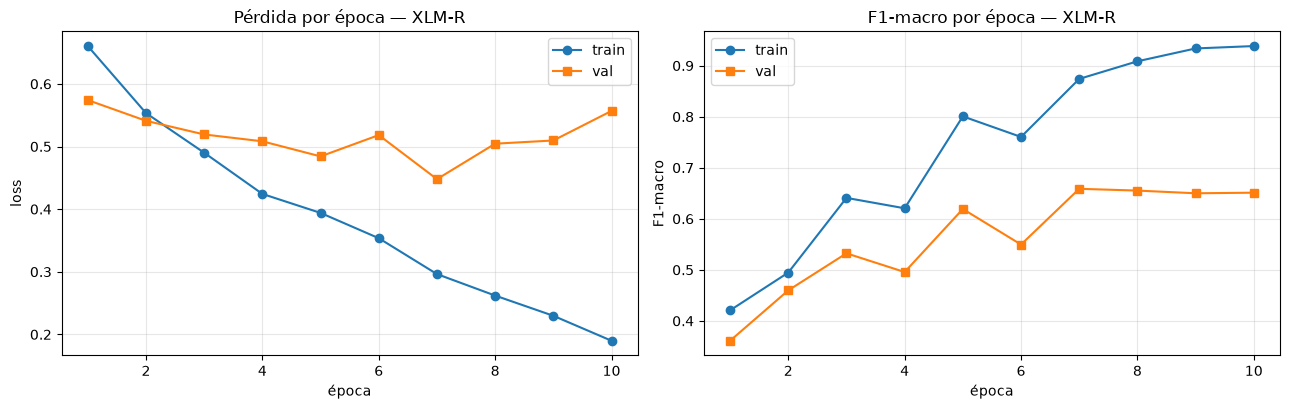

In [8]:
# ============================================================
# Curvas de entrenamiento / validación (XLM-R, loss y F1 por época)
# ============================================================
import sys, matplotlib.pyplot as plt
sys.path.insert(0, str(BASE_DIR / "scripts")); import absa_common as ac
VIS = BASE_DIR / "outputs" / "visualizations"; VIS.mkdir(parents=True, exist_ok=True)

hist_path = ac.art("xlmr", "hist")
if hist_path.exists():
    h = pd.read_csv(hist_path)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    ax[0].plot(h["epoch"], h["train_loss"], marker="o", label="train")
    ax[0].plot(h["epoch"], h["val_loss"], marker="s", label="val")
    ax[0].set_title("Pérdida por época — XLM-R"); ax[0].set_xlabel("época"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["epoch"], h["train_f1_macro"], marker="o", label="train")
    ax[1].plot(h["epoch"], h["val_f1_macro"], marker="s", label="val")
    ax[1].set_title("F1-macro por época — XLM-R"); ax[1].set_xlabel("época"); ax[1].set_ylabel("F1-macro")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(VIS / "fase2_curvas_entrenamiento_xlmr.png", dpi=300); plt.show()
else:
    print("Curvas: falta entrenar XLM-R (historial_xlmr_v4.csv).")

## 8. Estabilidad por semilla

,seed,f1_macro,accuracy,f1_negativo,recall_negativo,f1_neutro,recall_neutro,f1_positivo,recall_positivo
0,42,0.6403,0.6717,0.6260,0.6417,0.5290,0.4534,0.7658,0.8273
1,7,0.6562,0.6660,0.6394,0.7167,0.5952,0.6211,0.7341,0.6707
2,123,0.3149,0.3415,0.3301,0.2833,0.4139,0.7391,0.2007,0.1124
3,2024,0.6683,0.6830,0.6339,0.5917,0.6158,0.6770,0.7552,0.7309
4,77,0.6526,0.6736,0.6044,0.5667,0.5988,0.6211,0.7545,0.7590
5,2025,0.6502,0.6755,0.5689,0.5333,0.6195,0.6522,0.7621,0.7590
6,99,0.6655,0.6830,0.6286,0.5500,0.6149,0.6646,0.7530,0.7590


Media F1-macro: 0.6069 ± 0.1291 | estable (std <= 0.03): False


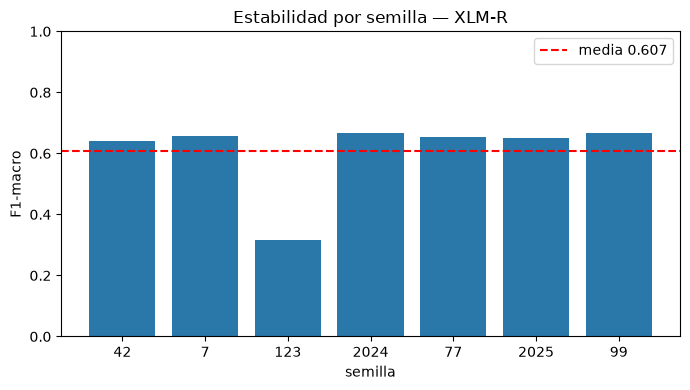

In [9]:
# ============================================================
# Estabilidad por semilla (media ± desviación estándar)
# ============================================================
det_path, res_path = ac.art("xlmr", "det"), ac.art("xlmr", "resumen")
if det_path.exists():
    det = pd.read_csv(det_path); res = pd.read_csv(res_path)
    display(det)
    m = float(res["media_f1_macro"].iloc[0]); s = float(res["std_f1_macro"].iloc[0])
    print(f"Media F1-macro: {m:.4f} ± {s:.4f} | estable (std <= 0.03): {bool(res['estable_std<=0.03'].iloc[0])}")
    plt.figure(figsize=(7, 4)); plt.bar(det["seed"].astype(str), det["f1_macro"], color="#2a77aa")
    plt.axhline(m, color="red", ls="--", label=f"media {m:.3f}")
    plt.ylim(0, 1); plt.ylabel("F1-macro"); plt.xlabel("semilla")
    plt.title("Estabilidad por semilla — XLM-R"); plt.legend()
    plt.tight_layout(); plt.savefig(VIS / "fase2_estabilidad_semillas_xlmr.png", dpi=300); plt.show()
else:
    print("Estabilidad: falta entrenar XLM-R.")

## 9. Veredicto vs especificación

In [10]:
# ============================================================
# Veredicto automático vs especificación (XLM-R ensemble calibrado)
# ============================================================
res_path = ac.art("xlmr", "resumen")
if res_path.exists():
    r = pd.read_csv(res_path).iloc[0]
    checks = {
        "F1-macro >= 0.70": float(r["ensemble_f1_macro"]) >= 0.70,
        "F1 negativo >= 0.60": float(r["ensemble_f1_negativo"]) >= 0.60,
        "recall negativo >= 0.60": float(r["ensemble_recall_negativo"]) >= 0.60,
        "F1 neutro >= 0.60": float(r["ensemble_f1_neutro"]) >= 0.60,
        "estable (std <= 0.03)": bool(r["estable_std<=0.03"]),
    }
    print("VEREDICTO vs ESPECIFICACIÓN (XLM-R + TextCNN, ensemble calibrado):")
    for k, v in checks.items():
        print(("  [OK] " if v else "  [NO] ") + k)
    print("\n=>", "XLM-R CUMPLE la especificación de forma estable." if all(checks.values())
          else "Versión base defendible (no alcanza todos los mínimos; se declara).")
else:
    print("Veredicto: falta entrenar XLM-R.")

VEREDICTO vs ESPECIFICACIÓN (XLM-R + TextCNN, ensemble calibrado):
  [NO] F1-macro >= 0.70
  [OK] F1 negativo >= 0.60
  [OK] recall negativo >= 0.60
  [OK] F1 neutro >= 0.60
  [NO] estable (std <= 0.03)

=> Versión base defendible (no alcanza todos los mínimos; se declara).


## 10. Veredicto

In [11]:
# ============================================================
# VEREDICTO
# ============================================================
print("=" * 56); print("ABSA POLARIDAD — VEREDICTO"); print("=" * 56)
print("Baselines (F1-macro):", {r["modelo"]: r["f1_macro"] for _, r in baselines_df.iterrows()})
if tiene_xlmr:
    rx = pd.read_csv(REP / "resumen_xlmr_v4.csv")
    print(f"XLM-R + TextCNN: ensemble F1-macro = {rx['ensemble_f1_macro'].iloc[0]:.4f} "
          f"(media {rx['media_f1_macro'].iloc[0]:.4f} ± {rx['std_f1_macro'].iloc[0]:.4f})")
    print("XLM-R supera a los baselines -> es el modelo de polaridad de la matriz (NB05).")
else:
    print("Falta entrenar XLM-R (GPU). El notebook queda completo y listo para ejecutarlo.")

ABSA POLARIDAD — VEREDICTO
Baselines (F1-macro): {'Mayoría': 0.2131, 'TF-IDF + LogReg': 0.5314, 'TF-IDF + SVM': 0.525}
XLM-R + TextCNN: ensemble F1-macro = 0.6928 (media 0.6069 ± 0.1291)
XLM-R supera a los baselines -> es el modelo de polaridad de la matriz (NB05).


## 11. Matriz destino-aspecto-sentimiento (insumo de Fase 3)

Tuplas (reseña x aspecto) detectadas en el corpus: 25632


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\danie\AppData\Local\Temp\ipykernel_23464\788594839.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Matriz destino-aspecto-sentimiento: (120, 17) -> outputs/matrices/


,destination,aspecto,n_menciones,n_reviews_unique,n_pos,n_neu,n_neg,pct_pos,pct_neu,pct_neg,sentiment_score,confidence,score_ajustado,score_normalizado_0_1,evidence_status,conflict_flag,dominant_label
0,Catarata de Ahuashiyacu,atractivos,609,609,604,2,3,99.18,0.33,0.49,0.9869,1.0,0.9869,0.9934,evidencia_suficiente,0,positivo
1,Catarata de Ahuashiyacu,costos,95,95,30,54,11,31.58,56.84,11.58,0.2000,1.0,0.2000,0.6000,evidencia_suficiente,0,neutro
2,Catarata de Ahuashiyacu,seguridad,65,65,15,45,5,23.08,69.23,7.69,0.1538,1.0,0.1538,0.5769,evidencia_suficiente,0,neutro
3,Catarata de Ahuashiyacu,accesibilidad,176,176,108,62,6,61.36,35.23,3.41,0.5795,1.0,0.5795,0.7898,evidencia_suficiente,0,positivo
4,Catarata de Ahuashiyacu,limpieza,105,105,66,39,0,62.86,37.14,0.00,0.6286,1.0,0.6286,0.8143,evidencia_suficiente,0,positivo
5,Catarata de Ahuashiyacu,atencion_servicio,59,59,30,29,0,50.85,49.15,0.00,0.5085,1.0,0.5085,0.7542,evidencia_suficiente,0,positivo
6,Catarata de Ahuashiyacu,gastronomia,85,85,22,62,1,25.88,72.94,1.18,0.2471,1.0,0.2471,0.6235,evidencia_suficiente,0,neutro
7,Catarata de Ahuashiyacu,alojamiento,2,2,2,0,0,100.00,0.00,0.00,1.0000,0.2,0.2000,0.6000,evidencia_insuficiente,0,positivo
8,Circuito Mágico del Agua,atractivos,777,777,693,49,35,89.19,6.31,4.50,0.8468,1.0,0.8468,0.9234,evidencia_suficiente,0,positivo
9,Circuito Mágico del Agua,costos,352,352,135,161,56,38.35,45.74,15.91,0.2244,1.0,0.2244,0.6122,evidencia_suficiente,0,neutro


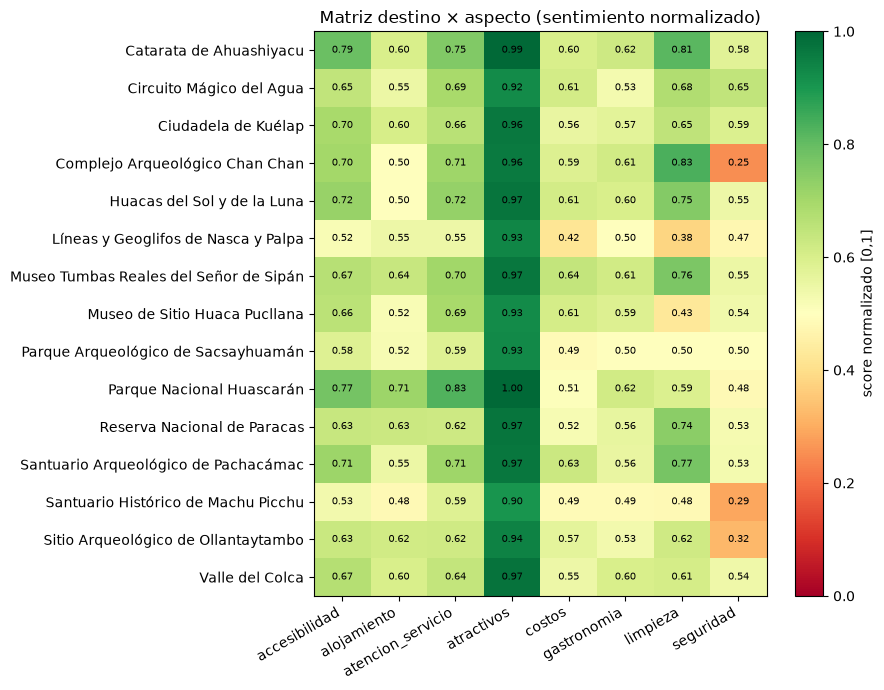

In [12]:
# ============================================================
# MATRIZ DESTINO-ASPECTO-SENTIMIENTO (insumo de Fase 3)
# ============================================================
# Detección de aspectos = DICCIONARIO (ganó a SBERT en NB02). Polaridad = XLM-R (ensemble).
# Requiere el modelo entrenado (models/modelo_xlmr_seed*_v4.pt).
import re, unicodedata, gc, json as _json
import torch
from torch.utils.data import DataLoader
GENERAR_MATRIZ = True
MATR = BASE_DIR / "outputs" / "matrices"; MATR.mkdir(parents=True, exist_ok=True)
modelos_pt = sorted((BASE_DIR / "models").glob("modelo_xlmr_seed*_v4.pt"))
if GENERAR_MATRIZ and modelos_pt:
    import absa_common as ac
    corpus = pd.read_csv(DATA_DIR / "tourism_reviews_clean.csv", encoding="utf-8-sig")
    dic = _json.load(open(DATA_DIR / "diccionario_aspectos.json", encoding="utf-8"))
    dic = {k: v for k, v in dic.items() if not str(k).startswith("_") and isinstance(v, list)}
    def _norm(t):
        t = unicodedata.normalize("NFKD", str(t).lower()); t = "".join(c for c in t if not unicodedata.combining(c))
        return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9ñ\s]", " ", t)).strip()
    PAT = {a: [(r"(?<!\w)" + re.escape(_norm(k.rstrip("*"))) + (r"\w*" if k.endswith("*") else r"(?!\w)"))
               for k in kws if _norm(k.rstrip("*"))] for a, kws in dic.items()}
    def _detect(t):
        tn = _norm(t); return [a for a, ps in PAT.items() if any(re.search(p, tn) for p in ps)]
    filas = []
    for _, r in corpus.iterrows():
        for a in _detect(r["text_clean"]):
            filas.append({"review_uid": r["review_uid"], "destination": r["destination"], "aspecto": a,
                          "input_modelo": f"aspecto: {a} reseña: {r['text_clean']}"})
    tuplas = pd.DataFrame(filas)
    print("Tuplas (reseña x aspecto) detectadas en el corpus:", len(tuplas))
    # Inferencia XLM-R ensemble
    tok = ac.AutoTokenizer.from_pretrained(ac.MODELOS["xlmr"])
    loader = DataLoader(ac.ABSADataset(tuplas["input_modelo"], None, tok), batch_size=ac.BATCH)
    probs = []
    for pt in modelos_pt:
        m = ac.TextCNN(ac.MODELOS["xlmr"]).to(ac.DEVICE)
        m.load_state_dict(torch.load(pt, map_location=ac.DEVICE));
        p, _, _ = ac.predict(m, loader); probs.append(p)
        del m; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    ens = np.mean(probs, 0)
    bias = np.load(ac.art("xlmr", "bias"))
    tuplas["polaridad"] = ac.apply_bias(ens, bias)
    # Agregación destino x aspecto con todas las combinaciones
    import itertools
    destinos = corpus["destination"].unique()
    aspectos = list(PAT.keys())
    todas_combinaciones = list(itertools.product(destinos, aspectos))
    
    agregado = {}
    for (d, a), g in tuplas.groupby(["destination", "aspecto"]):
        n = len(g)
        npos = int((g.polaridad == "positivo").sum())
        nneg = int((g.polaridad == "negativo").sum())
        nneu = int((g.polaridad == "neutro").sum())
        n_reviews_unique = g["review_uid"].nunique()
        agregado[(d, a)] = (n, npos, nneg, nneu, n_reviews_unique)
    out = []
    for d, a in todas_combinaciones:
        if (d, a) in agregado:
            n, npos, nneg, nneu, n_reviews_unique = agregado[(d, a)]
            score = (npos - nneg) / n if n else 0.0
            conf_flag = int(npos > 0 and nneg > 0 and min(npos, nneg) / n >= 0.25)
            conf = min(1.0, n / 10) * (0.65 if conf_flag else 1.0)
            adj = score * conf
            
            if n == 0: ev = "sin_datos"
            elif n < 5: ev = "evidencia_insuficiente"
            elif n < 10: ev = "baja_evidencia"
            else: ev = "evidencia_suficiente"
            
            dom = max([("negativo", nneg), ("neutro", nneu), ("positivo", npos)], key=lambda x: x[1])[0]
            pct_pos = round(npos / n * 100, 2) if n else 0.0
            pct_neu = round(nneu / n * 100, 2) if n else 0.0
            pct_neg = round(nneg / n * 100, 2) if n else 0.0
        else:
            n = npos = nneg = nneu = 0
            n_reviews_unique = 0
            score = conf = adj = 0.0
            conf_flag = 0
            ev = "sin_datos"
            dom = "neutro"
            pct_pos = pct_neu = pct_neg = 0.0
        out.append({"destination": d, "aspecto": a, "n_menciones": n, "n_reviews_unique": n_reviews_unique,
                    "n_pos": npos, "n_neu": nneu, "n_neg": nneg, 
                    "pct_pos": pct_pos, "pct_neu": pct_neu, "pct_neg": pct_neg,
                    "sentiment_score": round(score, 4), "confidence": round(conf, 4), "score_ajustado": round(adj, 4),
                    "score_normalizado_0_1": round((adj + 1) / 2, 4), "evidence_status": ev,
                    "conflict_flag": conf_flag, "dominant_label": dom})
    matriz = pd.DataFrame(out)
    matriz.to_csv(MATR / "matriz_destino_aspecto_sentimiento.csv", index=False, encoding="utf-8-sig")
    print("Matriz destino-aspecto-sentimiento:", matriz.shape, "-> outputs/matrices/")
    display(matriz.head(16))
    # Heatmap destino x aspecto (figura para la tesis)
    import matplotlib.pyplot as plt
    FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
    piv = matriz.pivot(index="destination", columns="aspecto", values="score_normalizado_0_1")
    plt.figure(figsize=(9, 7)); plt.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    plt.xticks(range(len(piv.columns)), piv.columns, rotation=30, ha="right")
    plt.yticks(range(len(piv.index)), piv.index)
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            v = piv.values[i, j]
            if pd.notna(v): plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(label="score normalizado [0,1]"); plt.title("Matriz destino × aspecto (sentimiento normalizado)")
    plt.tight_layout(); plt.savefig(FIG / "fase2_matriz_destino_aspecto.png", dpi=300); plt.show()
else:
    print("La matriz se genera tras entrenar XLM-R (models/ vacío) o con GENERAR_MATRIZ=False.")


## 12. Niveles de evidencia de la matriz

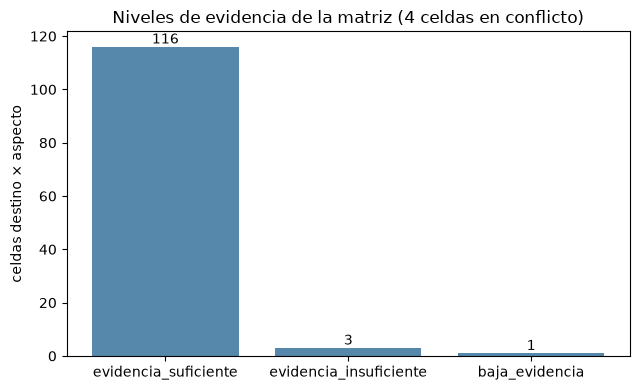

Resumen de evidencia: {'evidencia_suficiente': 116, 'evidencia_insuficiente': 3, 'baja_evidencia': 1}


In [13]:
# ============================================================
# Niveles de evidencia de la matriz (vista para la tesis)
# ============================================================
if "matriz" in dir() and isinstance(matriz, pd.DataFrame) and len(matriz):
    import matplotlib.pyplot as plt
    FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
    ev = matriz["evidence_status"].value_counts()
    conflict = int(matriz["conflict_flag"].sum())
    plt.figure(figsize=(6.5, 4)); plt.bar(ev.index, ev.values, color="#5588aa")
    for i, v in enumerate(ev.values): plt.text(i, v, str(v), ha="center", va="bottom")
    plt.title(f"Niveles de evidencia de la matriz ({conflict} celdas en conflicto)")
    plt.ylabel("celdas destino × aspecto"); plt.tight_layout()
    plt.savefig(FIG / "fase2_matriz_evidencia.png", dpi=300); plt.show()
    print("Resumen de evidencia:", ev.to_dict())
else:
    print("Niveles de evidencia: la matriz se genera tras entrenar XLM-R.")

## Conclusión metodológica

- **Detección de aspectos:** se adoptó el **diccionario** (superó a SBERT zero-shot en el gold, NB02:
  F1-macro 0.80 vs 0.41). Es más simple, auditable y empíricamente mejor en este dominio cerrado.
- **Polaridad:** **XLM-R + TextCNN** (sin BERT: ya se sabe que XLM-R es superior), con FocalLoss,
  refuerzo de la clase negativa, calibración y ensemble de 5 semillas. Se compara contra baselines
  (mayoría, TF-IDF + LogReg/SVM) donde XLM-R es el mejor.
- **Métrica principal:** F1-macro; se reportan además métricas por clase y por aspecto, estabilidad
  por semilla y veredicto contra la especificación.
- **Producto:** la **matriz destino-aspecto-sentimiento** (con `confidence`, `evidence_status` y
  `conflict_flag`) es el insumo estructurado de la **Fase 3**.

*Limitación declarada:* aspectos con poco soporte (p. ej. `gastronomia`/`alojamiento` con muy pocos
negativos) están limitados por el corpus, no por el modelo.